# Análise de dados de crédito


#### Contexto
Analisando dados de uma empresa do setor financeiro 
que opera cartões Private Label.

Nos últimos meses, a empresa observou: 
1. Aumento relevante na inadimplência da carteira 
2. Dúvidas sobre a qualidade das informações de renda dos clientes 
3. Pressão da diretoria para expandir a base de clientes e aumentar receita, 
sem elevar o risco de forma descontrolada

A base de dados contém essas informações para apoiar uma 
análise de revisão da política de crédito e, em decorrência das dúvidas sobre 
qualidade na informação de renda, um enriquecimento obtido através de um 
backtest do produto “Renda Presumida” de um Bureau de Crédito. 

**Objetivo**

O objetivo é analisar a base disponibilizada e desenvolver um diagnóstico 
aprofundado da carteira de clientes, com foco na identificação dos principais 
fatores que influenciam o risco de crédito e na avaliação da qualidade das 
informações disponíveis.

### Configurações do ambiente

#### Instalação das bibliotecas

In [42]:
!python.exe -m pip install --upgrade pip
%pip install pandas numpy pyarrow matplotlib seaborn openpyxl duckdb


Note: you may need to restart the kernel to use updated packages.


#### Importando bibliotecas e definindo aliases

In [43]:
import pandas as pd
import numpy as np
import pyarrow
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

### Base de clientes

#### Carregamento e leitura da planilha da base de clientes em carteira

In [44]:
clientes = pd.read_excel("infos_clientes.xlsx")

Visualização prévia da tabela

In [45]:
clientes.head()

,ID_Cliente,Data_Cadastro_Cliente,ID_Cartao,Data_Cadastro_Cartao,Status,PDV_Vendedor,Ramo_Vendedor,Ramo_1_Compra,Data_1_Compra,Venc_1_Compra,...,renda_backtest,uf,data_de_nascimento,limite_entrada,limite_atual,a_vencer_scr,vencido_scr,prejuizo_scr,limite_scr,quantidade_de_restricao
0,14105155,2025-05-19 16:14:21.497,8145848,2025-05-19 16:14:21.683,PROTESTO,42169,POPULAR,POPULAR,2025-05-31 13:41:42.340,2025-06-30,...,5570.0,AM,04/09/1988,200.00,200.0,3884.42,0.0,0.0,0.01,NaN
1,13638254,2025-03-20 17:17:19.000,7922702,2025-03-20 17:17:21.000,ATIVO,78633,POPULAR,POPULAR,2025-04-14 18:31:27.147,2025-05-10,...,1676.0,MT,09/05/1979,5077.80,6144.0,945.86,0.0,0.0,690.81,NaN
2,13663912,2025-03-24 17:01:45.507,7931455,2025-03-24 17:01:45.867,AGUARDANDO DESBLOQUEIO,85823,POPULAR,POPULAR,2025-03-24 18:00:21.220,2025-05-05,...,1227.0,AM,26/05/1979,400.00,675.0,19020.60,0.0,0.0,0.00,NaN
3,13870968,2025-04-22 11:12:49.000,8032161,2025-04-22 11:12:51.000,ATIVO,21268,POPULAR,POPULAR,2025-05-23 13:08:02.300,2025-06-30,...,8632.0,BA,20/01/1982,1629.45,3170.0,3936.46,0.0,0.0,97008.00,NaN
4,13822477,2025-04-14 09:56:08.483,8404203,2025-08-15 09:17:48.500,INADIMPLENTE,71916,POPULAR,POPULAR,2025-09-18 09:55:36.987,2025-10-30,...,2428.0,GO,01/10/1984,200.00,375.0,241.88,0.0,0.0,350.00,NaN


In [46]:
clientes.describe()

,ID_Cliente,Data_Cadastro_Cliente,ID_Cartao,Data_Cadastro_Cartao,PDV_Vendedor,Data_1_Compra,Venc_1_Compra,score,renda_informada,renda_backtest,limite_entrada,limite_atual,a_vencer_scr,vencido_scr,prejuizo_scr,limite_scr,quantidade_de_restricao
count,4.999400e+04,49994,4.999400e+04,49994,49994.000000,49994,49994,49993.000000,49994.000000,49836.000000,49994.000000,49994.000000,4.999400e+04,49994.000000,49994.000000,49994.000000,8687.000000
mean,1.369005e+07,2025-03-29 08:24:40.595586,7.983757e+06,2025-04-06 02:55:19.315482,59442.298096,2025-04-11 03:08:44.886809,2025-05-12 16:17:19.804776,463.835537,3859.238265,3480.097098,1508.964773,2105.154327,1.564838e+04,178.957715,346.985133,2041.479492,1.593070
min,1.291845e+07,2025-01-01 04:06:30,7.645820e+06,2025-01-01 10:27:12.633000,1580.000000,2025-01-01 15:21:29.843000,2025-01-20 00:00:00,-1.000000,0.000000,884.000000,0.010000,79.550000,0.000000e+00,0.000000,0.000000,0.000000,1.000000
25%,1.335000e+07,2025-02-12 09:06:26.540250,7.803977e+06,2025-02-14 16:11:55.721750,34633.000000,2025-02-17 19:14:18.521500,2025-03-20 00:00:00,345.000000,2000.000000,1320.000000,200.000000,480.000000,8.040925e+02,0.000000,0.000000,19.427500,1.000000
50%,1.369618e+07,2025-03-28 11:44:07.918000,7.988109e+06,2025-04-02 12:10:37.951500,59981.000000,2025-04-05 15:01:59.860000,2025-05-10 00:00:00,507.000000,3000.000000,2428.000000,1000.000000,1650.000000,3.334515e+03,0.000000,0.000000,445.775000,1.000000
75%,1.405460e+07,2025-05-13 10:45:55.429500,8.145908e+06,2025-05-19 16:28:48.720000,83475.000000,2025-05-24 11:22:32.412500,2025-06-30 00:00:00,655.000000,4100.000000,4448.000000,2274.127500,3020.040000,1.692383e+04,0.000000,0.000000,1600.000000,2.000000
max,1.442451e+07,2025-06-29 19:42:41.207000,8.848544e+06,2026-01-25 14:56:14,101346.000000,2026-02-23 15:29:50.580000,2026-04-05 00:00:00,999.000000,700000.000000,17754.000000,19310.900000,22598.000000,1.303630e+06,279445.000000,328536.000000,358147.000000,3.000000
std,4.208858e+05,NaN,2.098174e+05,NaN,22694.765397,NaN,NaN,266.906044,9899.775311,2715.346540,1649.948744,1984.354758,3.563546e+04,2144.719036,3731.537843,7717.055680,0.747588


In [47]:
clientes.dtypes

ID_Cliente                          int64
Data_Cadastro_Cliente      datetime64[us]
ID_Cartao                           int64
Data_Cadastro_Cartao       datetime64[us]
Status                                str
PDV_Vendedor                        int64
Ramo_Vendedor                         str
Ramo_1_Compra                         str
Data_1_Compra              datetime64[us]
Venc_1_Compra              datetime64[us]
score                             float64
situacao                              str
renda_informada                   float64
renda_backtest                    float64
uf                                    str
data_de_nascimento                    str
limite_entrada                    float64
limite_atual                      float64
a_vencer_scr                      float64
vencido_scr                       float64
prejuizo_scr                      float64
limite_scr                        float64
quantidade_de_restricao           float64
dtype: object

In [48]:
clientes.isnull().sum()

ID_Cliente                     0
Data_Cadastro_Cliente          0
ID_Cartao                      0
Data_Cadastro_Cartao           0
Status                         0
PDV_Vendedor                   0
Ramo_Vendedor                  0
Ramo_1_Compra                  0
Data_1_Compra                  0
Venc_1_Compra                  0
score                          1
situacao                       0
renda_informada                0
renda_backtest               158
uf                             0
data_de_nascimento             3
limite_entrada                 0
limite_atual                   0
a_vencer_scr                   0
vencido_scr                    0
prejuizo_scr                   0
limite_scr                     0
quantidade_de_restricao    41307
dtype: int64

#### Tratamentos da tabela de clientes

Limpando o cabeçalho da tabela

In [49]:
clientes.columns = clientes.columns.str.strip()

Preenchendo valores nulos com 0

In [50]:
clientes = clientes.fillna(0)

Convertendo a coluna 'data_de_nascimento' (str) em Date

In [51]:
clientes['data_de_nascimento'] = pd.to_datetime(
    clientes['data_de_nascimento'],
    format='%d/%m/%Y',
    errors='coerce'
)

clientes['data_de_nascimento']

0       1988-09-04
1       1979-05-09
2       1979-05-26
3       1982-01-20
4       1984-10-01
           ...    
49989   1951-06-29
49990   1984-08-21
49991   1989-03-13
49992   1954-03-18
49993   1960-03-14
Name: data_de_nascimento, Length: 49994, dtype: datetime64[us]

Removendo microssegundos das colunas de datetime

In [52]:
datas = [
    'Data_Cadastro_Cliente',
    'Data_Cadastro_Cartao',
    'Data_1_Compra',
    'Venc_1_Compra'
]

clientes[datas] = clientes[datas].apply(
    lambda col: col.dt.floor('s')
)

clientes[datas]

,Data_Cadastro_Cliente,Data_Cadastro_Cartao,Data_1_Compra,Venc_1_Compra
0,2025-05-19 16:14:21,2025-05-19 16:14:21,2025-05-31 13:41:42,2025-06-30
1,2025-03-20 17:17:19,2025-03-20 17:17:21,2025-04-14 18:31:27,2025-05-10
2,2025-03-24 17:01:45,2025-03-24 17:01:45,2025-03-24 18:00:21,2025-05-05
3,2025-04-22 11:12:49,2025-04-22 11:12:51,2025-05-23 13:08:02,2025-06-30
4,2025-04-14 09:56:08,2025-08-15 09:17:48,2025-09-18 09:55:36,2025-10-30
...,...,...,...,...
49989,2025-06-17 17:30:25,2025-06-17 17:31:56,2025-06-17 17:31:57,2025-07-10
49990,2025-03-27 18:36:19,2025-03-27 18:38:00,2025-03-27 18:38:01,2025-04-30
49991,2025-02-11 13:30:49,2025-02-11 13:46:51,2025-02-11 13:46:51,2025-03-10
49992,2025-04-29 12:16:03,2025-04-29 12:59:21,2025-04-29 13:11:48,2025-05-30


#### Testando hipóteses e fazendo validações

##### Perfil demográfico

Vamos analisar a distribuição de idades dos clientes no geral

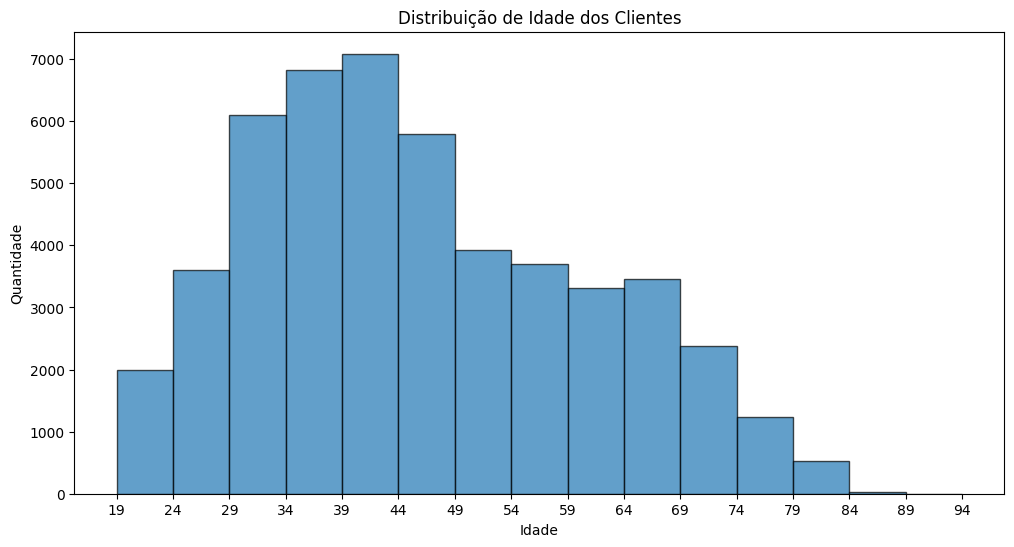

In [53]:
hoje = pd.Timestamp.today()

clientes['idade_atual'] = (
    (
        hoje - clientes['data_de_nascimento']
    ).dt.days // 365
)


plt.figure(figsize=(12,6))

bins = np.arange(
    clientes['idade_atual'].min(),
    clientes['idade_atual'].max() + 5,
    5
)

clientes['idade_atual'].plot(
    kind='hist',
    bins=bins,
    alpha=0.7,
    edgecolor='black'
)

plt.title('Distribuição de Idade dos Clientes')
plt.xlabel('Idade')
plt.ylabel('Quantidade')

plt.xticks(bins)

plt.show()

Percebe-se que existem clientes bem distribuidos entre diferentes idade, sendo que a maioria possui aproximadamente 30 - 45 anos de idade. Não estão concentrados nas extremidades.

Mas eles figuram entre os maiores inadimplentes? Vejamos:

Filtrando clientes com Status PROTESTO e INADIMPLENTE

In [54]:
filtro = clientes[
    clientes['Status']
    .str.upper()
    .isin(['PROTESTO', 'INADIMPLENTE'])
]

Validando os indices de inadimplência por faixa etária.

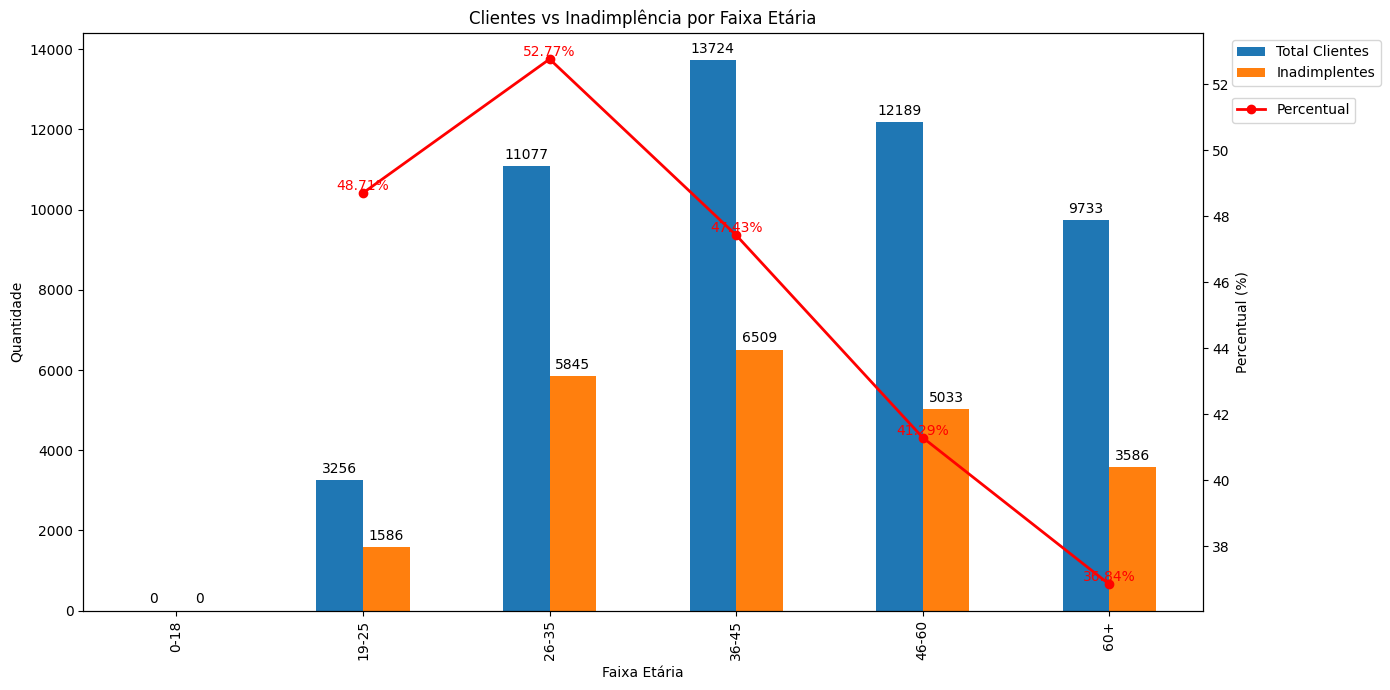

In [55]:
clientes['faixa_etaria'] = pd.cut(
    clientes['idade_atual'],
    bins=[0,18,25,35,45,60,100],
    labels=[
        '0-18',
        '19-25',
        '26-35',
        '36-45',
        '46-60',
        '60+'
    ]
)

filtro['faixa_etaria'] = pd.cut(
    filtro['idade_atual'],
    bins=[0,18,25,35,45,60,100],
    labels=[
        '0-18',
        '19-25',
        '26-35',
        '36-45',
        '46-60',
        '60+'
    ]
)

# total por faixa etária
total_faixa = (
    clientes['faixa_etaria']
    .value_counts()
    .sort_index()
)

# inadimplentes por faixa etária
inadimplentes_faixa = (
    filtro['faixa_etaria']
    .value_counts()
    .reindex(total_faixa.index)
    .fillna(0)
)

# percentual
percentual = (
    inadimplentes_faixa / total_faixa * 100
).round(2)

# dataframe comparativo
comparativo = pd.DataFrame({
    'Total Clientes': total_faixa,
    'Inadimplentes': inadimplentes_faixa
})

# gráfico
fig, ax1 = plt.subplots(figsize=(14,7))

# barras lado a lado
comparativo.plot(
    kind='bar',
    ax=ax1
)

ax1.set_title('Clientes vs Inadimplência por Faixa Etária')
ax1.set_xlabel('Faixa Etária')
ax1.set_ylabel('Quantidade')

# rótulos nas barras
for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%.0f',
        padding=3
    )

# eixo secundário
ax2 = ax1.twinx()

# linha percentual
percentual.plot(
    kind='line',
    marker='o',
    color='red',
    linewidth=2,
    ax=ax2
)

ax2.set_ylabel('Percentual (%)')

# rótulos da linha
for i, valor in enumerate(percentual):
    ax2.text(
        i,
        valor,
        f'{valor:.2f}%',
        color='red',
        ha='center',
        va='bottom'
    )

# legendas fora do gráfico
ax1.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

ax2.legend(
    ['Percentual'],
    loc='upper left',
    bbox_to_anchor=(1.02, 0.9)
)

plt.tight_layout()
plt.show()

Confirmado. Além de serem maioria na carteira de clientes, os maiores percentuais de inadimplência estão nessa parcela de clientes.

Podemos verificar também quanto a situação dos clientes. Temos suspeitas de que os clientes desempregados ou sem emprego fixo podem encontrar dificuldades para manter as contas em dia.
Vejamos se confere:

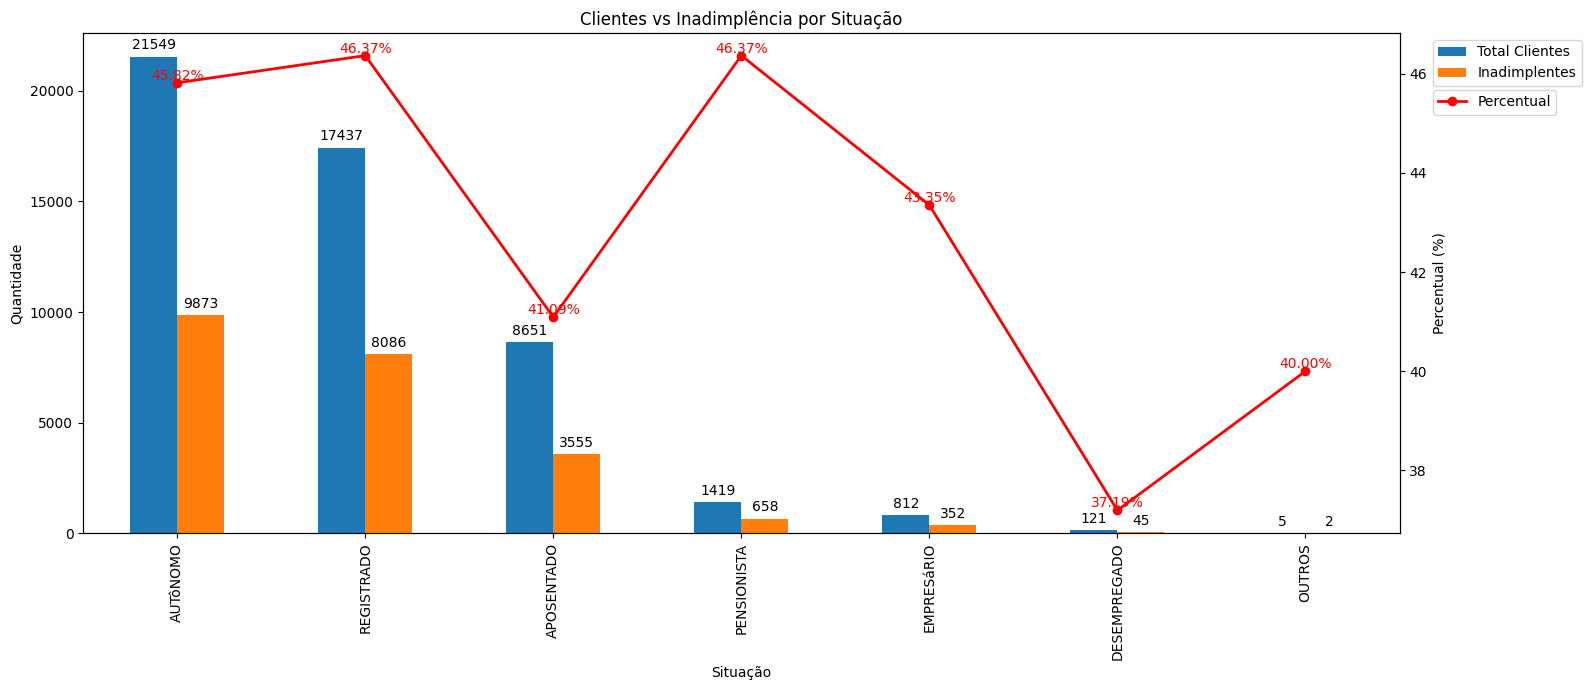

In [56]:
# total por situação
total_situacao = (
    clientes['situacao']
    .value_counts()
    .sort_values(ascending=False)
)

# inadimplentes por situação
inadimplentes_situacao = (
    filtro['situacao']
    .value_counts()
    .reindex(total_situacao.index)
    .fillna(0)
)

# percentual
percentual = (
    inadimplentes_situacao / total_situacao * 100
).round(2)

# dataframe comparativo
comparativo = pd.DataFrame({
    'Total Clientes': total_situacao,
    'Inadimplentes': inadimplentes_situacao
})

# gráfico
fig, ax1 = plt.subplots(figsize=(16,7))

# barras lado a lado
comparativo.plot(
    kind='bar',
    ax=ax1
)

ax1.set_title('Clientes vs Inadimplência por Situação')
ax1.set_xlabel('Situação')
ax1.set_ylabel('Quantidade')

# rótulos barras
for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%.0f',
        padding=3
    )

# eixo secundário
ax2 = ax1.twinx()

# linha percentual
percentual.plot(
    kind='line',
    marker='o',
    color='red',
    linewidth=2,
    ax=ax2
)

ax2.set_ylabel('Percentual (%)')

# rótulos linha
for i, valor in enumerate(percentual):
    ax2.text(
        i,
        valor,
        f'{valor:.2f}%',
        color='red',
        ha='center',
        va='bottom'
    )

# legendas externas
ax1.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

ax2.legend(
    ['Percentual'],
    loc='upper left',
    bbox_to_anchor=(1.02, 0.9)
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Interessante. Na verdade os maiores inadimplentes empatados são os clientes que declararam serem registrados e pensionistas, seguidos pelos autônomos.
Podemos supor que os demais preferem não fazer muitas dívidas justamente pela incerteza de suas situações instáveis, em contraste com a maioria apresentada.

Os desempregados representam uma parcela muito pequena da carteira, possivelmente por não conseguirem crédito, visto que, não geram renda a ser comprovada.

Outro dado disponível é o UF (estado dos clientes), vejamos em qual região se encontra os maiores índices.

Segmentando as regiões

In [57]:
mapa_regiao = {
    # Norte
    'AC': 'Norte',
    'AP': 'Norte',
    'AM': 'Norte',
    'PA': 'Norte',
    'RO': 'Norte',
    'RR': 'Norte',
    'TO': 'Norte',

    # Nordeste
    'AL': 'Nordeste',
    'BA': 'Nordeste',
    'CE': 'Nordeste',
    'MA': 'Nordeste',
    'PB': 'Nordeste',
    'PE': 'Nordeste',
    'PI': 'Nordeste',
    'RN': 'Nordeste',
    'SE': 'Nordeste',

    # Centro-Oeste
    'DF': 'Centro-Oeste',
    'GO': 'Centro-Oeste',
    'MT': 'Centro-Oeste',
    'MS': 'Centro-Oeste',

    # Sudeste
    'ES': 'Sudeste',
    'MG': 'Sudeste',
    'RJ': 'Sudeste',
    'SP': 'Sudeste',

    # Sul
    'PR': 'Sul',
    'RS': 'Sul',
    'SC': 'Sul'
}

clientes['regiao'] = clientes['uf'].map(mapa_regiao)
filtro['regiao'] = clientes['uf'].map(mapa_regiao)

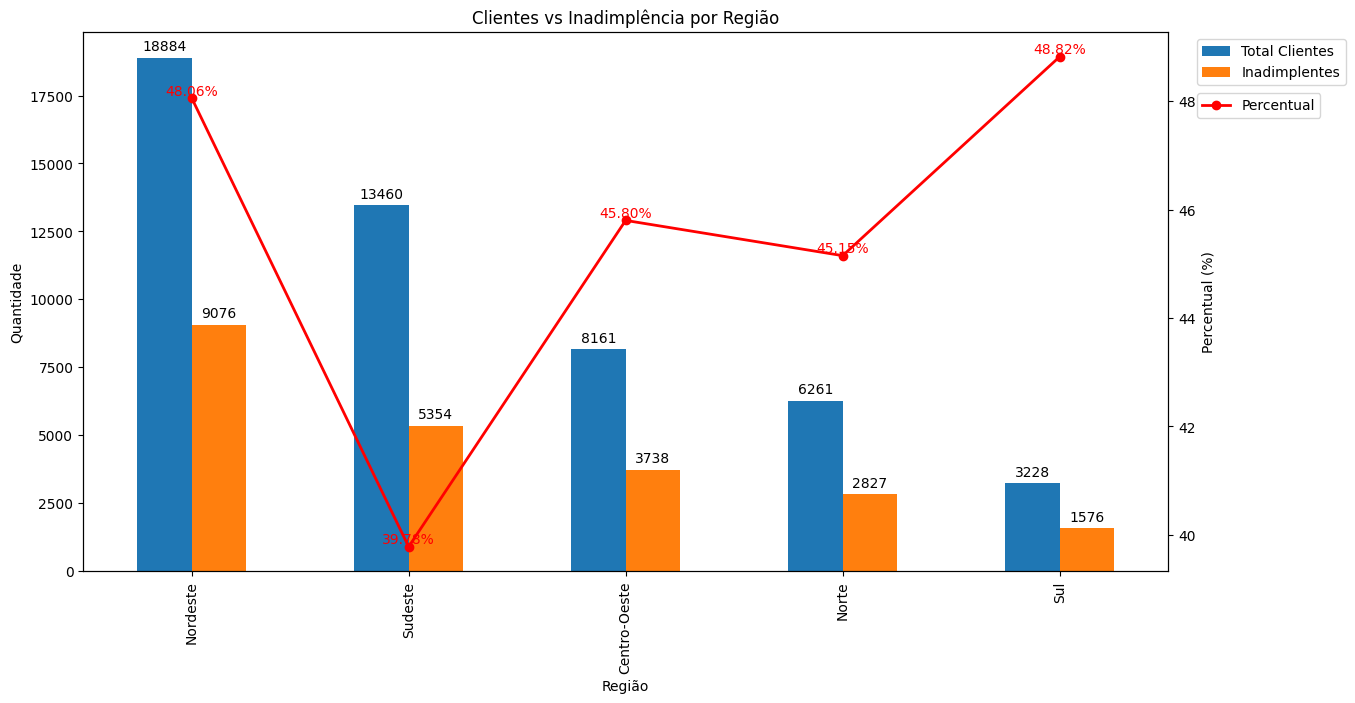

In [58]:
total_regiao = (
    clientes['regiao']
    .value_counts()
    .sort_values(ascending=False)
)

inadimplentes_regiao = (
    filtro['regiao']
    .value_counts()
    .reindex(total_regiao.index)
    .fillna(0)
)

percentual = (
    inadimplentes_regiao / total_regiao * 100
).round(2)

comparativo = pd.DataFrame({
    'Total Clientes': total_regiao,
    'Inadimplentes': inadimplentes_regiao
})

# gráfico
fig, ax1 = plt.subplots(figsize=(14,7))

comparativo.plot(
    kind='bar',
    ax=ax1
)

ax1.set_title('Clientes vs Inadimplência por Região')
ax1.set_xlabel('Região')
ax1.set_ylabel('Quantidade')

# rótulos nas barras
for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%.0f',
        padding=3
    )

# eixo secundário
ax2 = ax1.twinx()

percentual.plot(
    kind='line',
    marker='o',
    color='red',
    linewidth=2,
    ax=ax2
)

ax2.set_ylabel('Percentual (%)')

# rótulos na linha
for i, valor in enumerate(percentual):
    ax2.text(
        i,
        valor,
        f'{valor:.2f}%',
        color='red',
        ha='center',
        va='bottom'
    )

# legenda
ax1.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

ax2.legend(
    ['Percentual'],
    loc='upper left',
    bbox_to_anchor=(1.02, 0.9)
)

plt.subplots_adjust(right=0.9)
plt.show()

Os clientes do Nordeste e Sudeste são maioria. Porém, em termos de inadimplência apesar ser menos representativa em volume, proporcionalmente a região Sul lidera em localização dos mais inadimplentes.

##### Perfil financeiro

A variavel de pontuação de score é uma das mais analisadas. Pois mede exatamente o comportamento financeiro do indivíduo. Podemos ver se há alguma ligação com indices altos de inadimplência.

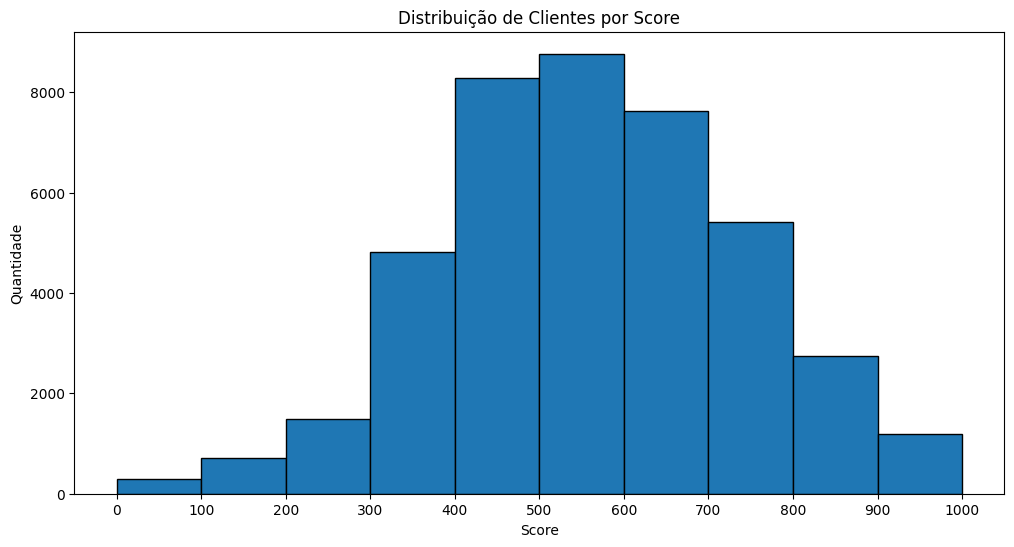

In [59]:
plt.figure(figsize=(12,6))

bins = np.arange(0, 1001, 100)

clientes['score'].plot(
    kind='hist',
    bins=bins,
    edgecolor='black'
)

plt.title('Distribuição de Clientes por Score')
plt.xlabel('Score')
plt.ylabel('Quantidade')

plt.xticks(bins)

plt.show()

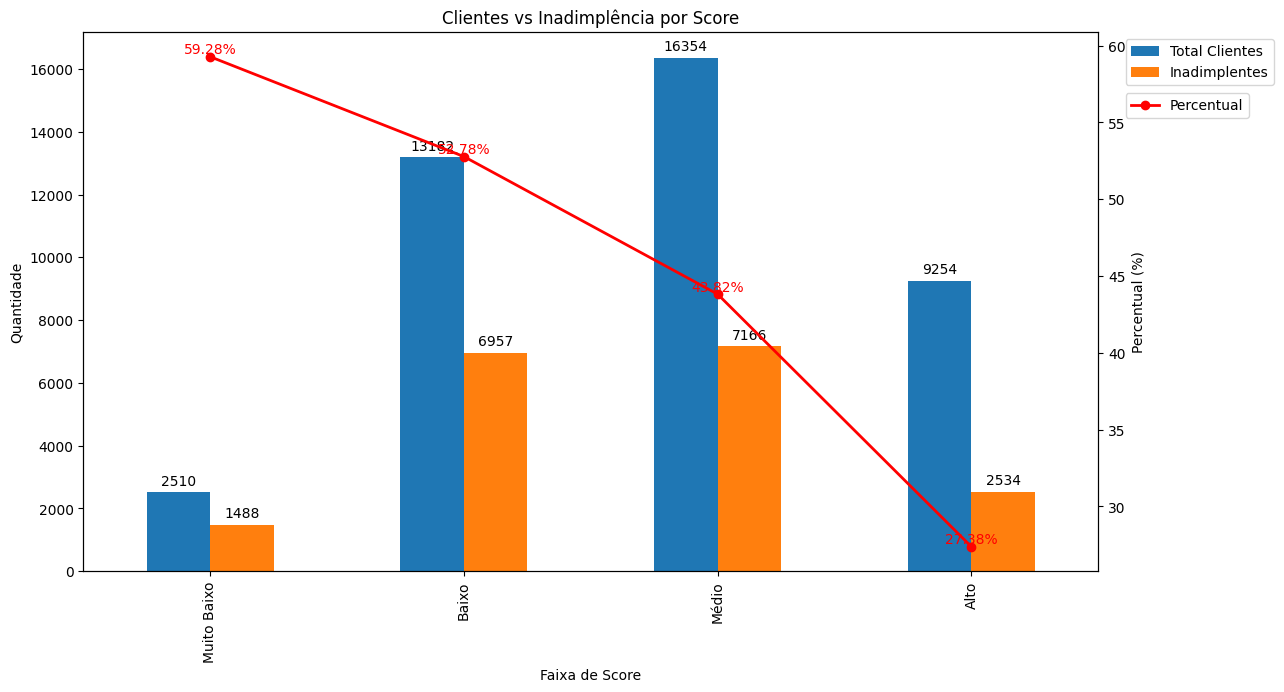

In [60]:
clientes['faixa_score'] = pd.cut(
    clientes['score'],
    bins=[0,300,500,700,1000],
    labels=[
        'Muito Baixo',
        'Baixo',
        'Médio',
        'Alto'
    ]
)

filtro['faixa_score'] = pd.cut(
    filtro['score'],
    bins=[0,300,500,700,1000],
    labels=[
        'Muito Baixo',
        'Baixo',
        'Médio',
        'Alto'
    ]
)

# totais por score
total_score = (
    clientes['faixa_score']
    .value_counts()
    .sort_index()
)

# inadimplentes por score
inadimplentes_score = (
    filtro['faixa_score']
    .value_counts()
    .reindex(total_score.index)
    .fillna(0)
)

# percentual
percentual = (
    inadimplentes_score / total_score * 100
).round(2)

# dataframe comparativo
comparativo = pd.DataFrame({
    'Total Clientes': total_score,
    'Inadimplentes': inadimplentes_score
})

# gráfico
fig, ax1 = plt.subplots(figsize=(14,7))

comparativo.plot(
    kind='bar',
    ax=ax1
)

ax1.set_title('Clientes vs Inadimplência por Score')
ax1.set_xlabel('Faixa de Score')
ax1.set_ylabel('Quantidade')

# rótulos nas barras
for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%.0f',
        padding=3
    )

# eixo secundário
ax2 = ax1.twinx()

# linha percentual
percentual.plot(
    kind='line',
    marker='o',
    color='red',
    linewidth=2,
    ax=ax2
)

ax2.set_ylabel('Percentual (%)')

# rótulos da linha
for i, valor in enumerate(percentual):
    ax2.text(
        i,
        valor,
        f'{valor:.2f}%',
        color='red',
        ha='center',
        va='bottom'
    )

# legendas fora
ax1.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

ax2.legend(
    ['Percentual'],
    loc='upper left',
    bbox_to_anchor=(1.02, 0.9)
)

plt.subplots_adjust(right=0.85)

plt.show()

De fato quanto menor a faixa do score em que o cliente está enquadrado maior a taxa de inadimplência.

### Base de movimentações de cartões

#### Carregamento e Leitura do parquet de movimentações de cartões (compras e pagamentos/ recebimento)

In [61]:
movimentacoes = pd.read_parquet("base_compras_pagamentos.parquet", engine="pyarrow")

In [62]:
movimentacoes

,Ctrl_ClienteCartao,Vencimento,Valor_Compra,Valor_Recebimento
0,7645820,2025-01-20,50.03,64.93
1,7645820,2025-02-20,120.65,135.55
2,7645820,2025-04-20,358.50,388.30
3,7645820,2025-05-20,362.37,NaN
4,7645820,2025-06-20,100.76,NaN
...,...,...,...,...
476336,8828658,2026-09-05,331.62,NaN
476337,8828658,2026-10-05,331.62,NaN
476338,8828658,2026-11-05,331.57,NaN
476339,8848544,2026-03-30,98.78,NaN


#### Tratamento da base de movimentações

Limpando o cabeçalho da tabela

In [63]:
movimentacoes.columns = movimentacoes.columns.str.strip()

Preenchendo os valores nulos com 0

In [64]:
movimentacoes = movimentacoes.fillna(0)
movimentacoes

,Ctrl_ClienteCartao,Vencimento,Valor_Compra,Valor_Recebimento
0,7645820,2025-01-20,50.03,64.93
1,7645820,2025-02-20,120.65,135.55
2,7645820,2025-04-20,358.50,388.30
3,7645820,2025-05-20,362.37,0.00
4,7645820,2025-06-20,100.76,0.00
...,...,...,...,...
476336,8828658,2026-09-05,331.62,0.00
476337,8828658,2026-10-05,331.62,0.00
476338,8828658,2026-11-05,331.57,0.00
476339,8848544,2026-03-30,98.78,0.00


#### Testando hipóteses e fazendo validações

In [65]:
### Clientes com valores pagos mas sem valor de compra informado
pagto_sem_compra_informada = movimentacoes[movimentacoes['Valor_Compra']<=0]['Ctrl_ClienteCartao'].count()

### Clientes com valores pagos maiores que o valor de compra informado
pagto_maiores_que_compras = movimentacoes[movimentacoes['Valor_Compra']<movimentacoes['Valor_Recebimento']]['Ctrl_ClienteCartao'].count()

print("Pagto. sem compra infomada: ",pagto_sem_compra_informada)
print("Pagto. mais altos que o valor da compra: ",pagto_maiores_que_compras)



Pagto. sem compra infomada:  7789
Pagto. mais altos que o valor da compra:  240967


Pode-se observar que há movimentações de pagamentos que não apresentam o valor da compra. 
Possivelmente, não estavam previstos e/ou a informação do valor de compra se perdeu. 

Também, é possível identificar dentre as movimentações, valores pagos maiores que o valor da compra.
Podendo se tratar de juros e/ou multas sobre atraso mas não está explícito, visto que os valores estão agregados e não possuímos a informação de data do pagamento para validar se foi realizado após o vencimento e se sim, quanto tempo depois, se foi integral ou parcialmente quitada.

### Cruzamento de dados - Merge das Tabelas

Verificação de tipos das chaves para join das tabelas

In [66]:
clientes['ID_Cartao'].dtype
movimentacoes['Ctrl_ClienteCartao'].dtype

dtype('int64')

Criação de métricas de movimentações

In [67]:
metricas = (
    movimentacoes.groupby('Ctrl_ClienteCartao')
       .agg(
           qtde_compras=('Ctrl_ClienteCartao', 'count'),
           valor_em_compras=('Valor_Compra', 'sum'),
           ticket_medio=('Valor_Compra', 'mean'),
           valor_recebimento=('Valor_Recebimento', 'sum'),
       )
       .reset_index()
)

clientes_mov = clientes.merge(
    metricas,
    left_on='ID_Cartao',
    right_on='Ctrl_ClienteCartao',
    how='left'
)

clientes_mov.head()

,ID_Cliente,Data_Cadastro_Cliente,ID_Cartao,Data_Cadastro_Cartao,Status,PDV_Vendedor,Ramo_Vendedor,Ramo_1_Compra,Data_1_Compra,Venc_1_Compra,...,quantidade_de_restricao,idade_atual,faixa_etaria,regiao,faixa_score,Ctrl_ClienteCartao,qtde_compras,valor_em_compras,ticket_medio,valor_recebimento
0,14105155,2025-05-19 16:14:21,8145848,2025-05-19 16:14:21,PROTESTO,42169,POPULAR,POPULAR,2025-05-31 13:41:42,2025-06-30,...,0.0,37.0,36-45,Norte,Muito Baixo,8145848,3,345.21,115.070000,158.82
1,13638254,2025-03-20 17:17:19,7922702,2025-03-20 17:17:21,ATIVO,78633,POPULAR,POPULAR,2025-04-14 18:31:27,2025-05-10,...,0.0,47.0,46-60,Centro-Oeste,Baixo,7922702,22,6843.90,311.086364,1875.71
2,13663912,2025-03-24 17:01:45,7931455,2025-03-24 17:01:45,AGUARDANDO DESBLOQUEIO,85823,POPULAR,POPULAR,2025-03-24 18:00:21,2025-05-05,...,0.0,46.0,46-60,Norte,Médio,7931455,13,2761.34,212.410769,2807.31
3,13870968,2025-04-22 11:12:49,8032161,2025-04-22 11:12:51,ATIVO,21268,POPULAR,POPULAR,2025-05-23 13:08:02,2025-06-30,...,0.0,44.0,36-45,Nordeste,Baixo,8032161,8,4528.48,566.060000,4528.93
4,13822477,2025-04-14 09:56:08,8404203,2025-08-15 09:17:48,INADIMPLENTE,71916,POPULAR,POPULAR,2025-09-18 09:55:36,2025-10-30,...,0.0,41.0,36-45,Centro-Oeste,Muito Baixo,8404203,5,633.73,126.746000,382.04


In [68]:
qtde_clientes = clientes_mov['ID_Cliente'].count()
clientes_sem_mov = clientes_mov[clientes_mov['qtde_compras'] < 0]['ID_Cliente'].count()

print("Quantidade total de clientes: ", qtde_clientes)
print("Quantidade de clientes sem movimentação: ", clientes_sem_mov)


Quantidade total de clientes:  49994
Quantidade de clientes sem movimentação:  0


Inserindo coluna numérica para representar a inadimplencia e observar as correlações

In [69]:
clientes_mov['inadimplente_bin'] = clientes['Status'].str.upper().isin(
    ['PROTESTO', 'INADIMPLENTE']
).astype(int)

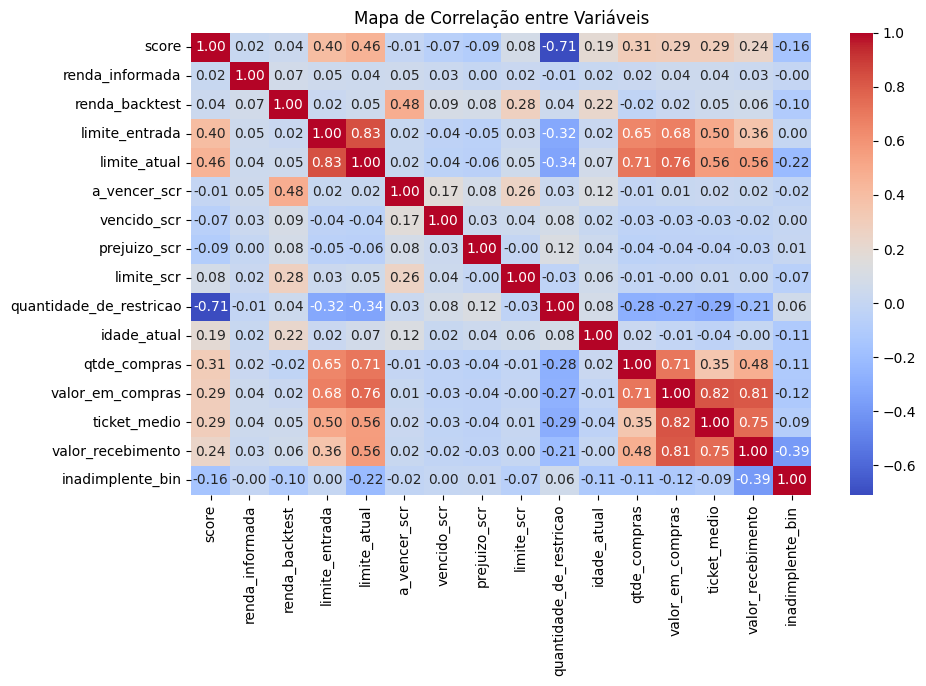

In [70]:
df_corr = clientes_mov.drop(
    ['ID_Cliente', 'PDV_Vendedor', 'ID_Cartao', 'Ctrl_ClienteCartao'],
    axis=1,
    errors='ignore'
)

df_corr = df_corr.select_dtypes(include='number').dropna()

corr = df_corr.corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Mapa de Correlação entre Variáveis')

plt.show()

1. O gráfico revela uma correlação negativa entre a quantidade de restrições e score (quanto mais baixo, mais restrições) e positiva relacionada ao consumo em relação aos limites inicial e atual e a quatidade de compras, ticket médio e recebimentos.
2. Porém, não nos mostra nenhuma correlação entre as variáveis forte o bastante, seja positiva ou negativa com a inadimplência, ao ponto de ser relevante.

##### Considerações finais

Essa análise permite concluir que ao relacionar fatores isolados com o status de inadimplência podemos perceber que os maiores inadimplentes são:

1. Clientes com a faixa etária de 30 - 45 anos.
2. Clientes localizados na região sul do Brasil.
3. Clientes autonomos, registrados e pensionistas.
3. Clientes com pontuações de score mais baixas e maiores quantidades de retrições.

Sendo assim, nenhuma outra váriavel inesperada foi identificada tendo correlação forte com a inadimplência, aumentando o risco.